## FIE Classifier Training — POET vs XGBoost

### Install Dependencies

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib --quiet
print("All dependencies installed.")

All dependencies installed.


### Imports

In [1]:
import json
import os
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

# Research-oriented color palette (muted/pastel, print-safe)
RC = {
    "correct"  : "#AEC6CF",  # powder blue  — correct answers
    "failure"  : "#D4888A",  # muted rose   — failure cases
    "poet"     : "#D4A96A",  # muted amber  — POET baseline marker
    "default"  : "#9B84B0",  # muted lavender — XGBoost default threshold
    "best_f1"  : "#7FB68A",  # muted sage   — best-F1 threshold
    "poet_fpr" : "#7BA7BC",  # steel blue   — POET-matched FPR threshold
    "roc_line" : "#4C6FA5",  # navy blue    — ROC curve
    "neutral"  : "#AAAAAA",  # gray         — reference lines
}

plt.rcParams["figure.dpi"]        = 120
plt.rcParams["font.size"]         = 11
plt.rcParams["font.family"]       = "serif"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.prop_cycle"]   = plt.cycler(color=list(RC.values()))

print("Imports done.")

Imports done.


### Load Labeled Data

In [2]:
import glob
LABELED_DIR = "../data/labeled/"
jsonl_files = sorted(glob.glob(LABELED_DIR + "synthetic_*.jsonl"))

if not jsonl_files:
    raise FileNotFoundError(f"No synthetic_*.jsonl files found in {LABELED_DIR}")

print(f"Found {len(jsonl_files)} JSONL file(s):")
for f in jsonl_files:
    print(f"  {f}")
print()

# Load all files and deduplicate by question+label_type
seen = set()
records = []

for fpath in jsonl_files:
    with open(fpath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            # Deduplicate: same question + same label_type = skip
            key = (r.get("question",""), r.get("label_type",""))
            if key not in seen:
                seen.add(key)
                records.append(r)

print(f"Total unique records loaded: {len(records)}")
print(f"Keys in each record        : {list(records[0].keys())}")
print()

from collections import Counter
outcomes = Counter(r["outcome"] for r in records)
print("Outcome distribution:")
for k, v in sorted(outcomes.items()):
    print(f"  {k:<22} : {v}")


Found 18 JSONL file(s):
  ../data/labeled\synthetic_20260410_012109.jsonl
  ../data/labeled\synthetic_20260414_215247.jsonl
  ../data/labeled\synthetic_20260415_125829.jsonl
  ../data/labeled\synthetic_20260415_131209.jsonl
  ../data/labeled\synthetic_20260415_211921.jsonl
  ../data/labeled\synthetic_20260415_213114.jsonl
  ../data/labeled\synthetic_20260418_114358.jsonl
  ../data/labeled\synthetic_20260418_121643.jsonl
  ../data/labeled\synthetic_20260418_122547.jsonl
  ../data/labeled\synthetic_20260418_124312.jsonl
  ../data/labeled\synthetic_20260418_175434.jsonl
  ../data/labeled\synthetic_20260418_224046.jsonl
  ../data/labeled\synthetic_20260418_230020.jsonl
  ../data/labeled\synthetic_20260418_233646.jsonl
  ../data/labeled\synthetic_20260419_000027.jsonl
  ../data/labeled\synthetic_20260419_002200.jsonl
  ../data/labeled\synthetic_20260419_144437.jsonl
  ../data/labeled\synthetic_20260420_184556.jsonl

Total unique records loaded: 869
Keys in each record        : ['label_type'

### Exploratory Data Analysis

In [3]:
# Build flat dataframe for EDA
rows = []
for r in records:
    fr = r["fie_result"]
    rows.append({
        # Target
        "label"             : int(r["fie_should_detect"]),   # 1=failure, 0=correct
        "outcome"           : r["outcome"],
        # Numeric signals
        "agreement_score"   : fr.get("agreement_score",   1.0),
        "entropy_score"     : fr.get("entropy_score",     0.0),
        "jury_confidence"   : fr.get("jury_confidence",   0.0),
        "fix_confidence"    : fr.get("fix_confidence",    0.0),
        "gt_confidence"     : fr.get("gt_confidence",     0.0),
        # Boolean signals
        "high_failure_risk" : int(fr.get("high_failure_risk",   False)),
        "fix_applied"       : int(fr.get("fix_applied",         False)),
        "requires_escalation": int(fr.get("requires_escalation", False)),
        "gt_override"       : int(fr.get("gt_override",         False)),
        # Categorical signals
        "archetype"         : fr.get("archetype",     "NONE") or "NONE",
        "jury_verdict"      : fr.get("jury_verdict",  "NONE") or "NONE",
        "fix_strategy"      : fr.get("fix_strategy",  "NONE") or "NONE",
        "gt_source"         : fr.get("gt_source",     "none") or "none",
        "category"          : r.get("category",       "unknown"),
    })

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print()
print("Class balance:")
print(df["label"].value_counts().rename({1: "Failure (1)", 0: "Correct (0)"}))
print()
df.describe()

DataFrame shape: (869, 16)

Class balance:
label
Failure (1)    435
Correct (0)    434
Name: count, dtype: int64



,label,agreement_score,entropy_score,jury_confidence,fix_confidence,gt_confidence,high_failure_risk,fix_applied,requires_escalation,gt_override
count,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.00000
mean,0.500575,0.747126,0.413887,0.421153,0.235013,0.274818,0.492520,0.303797,0.150748,0.24626
std,0.500288,0.242712,0.390895,0.270638,0.382674,0.422780,0.500232,0.460161,0.358009,0.43108
min,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,0.500000,0.000000,0.222800,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,1.000000,0.750000,0.405600,0.415300,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,1.000000,1.000000,0.750000,0.591500,0.439800,0.800000,1.000000,1.000000,0.000000,0.00000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


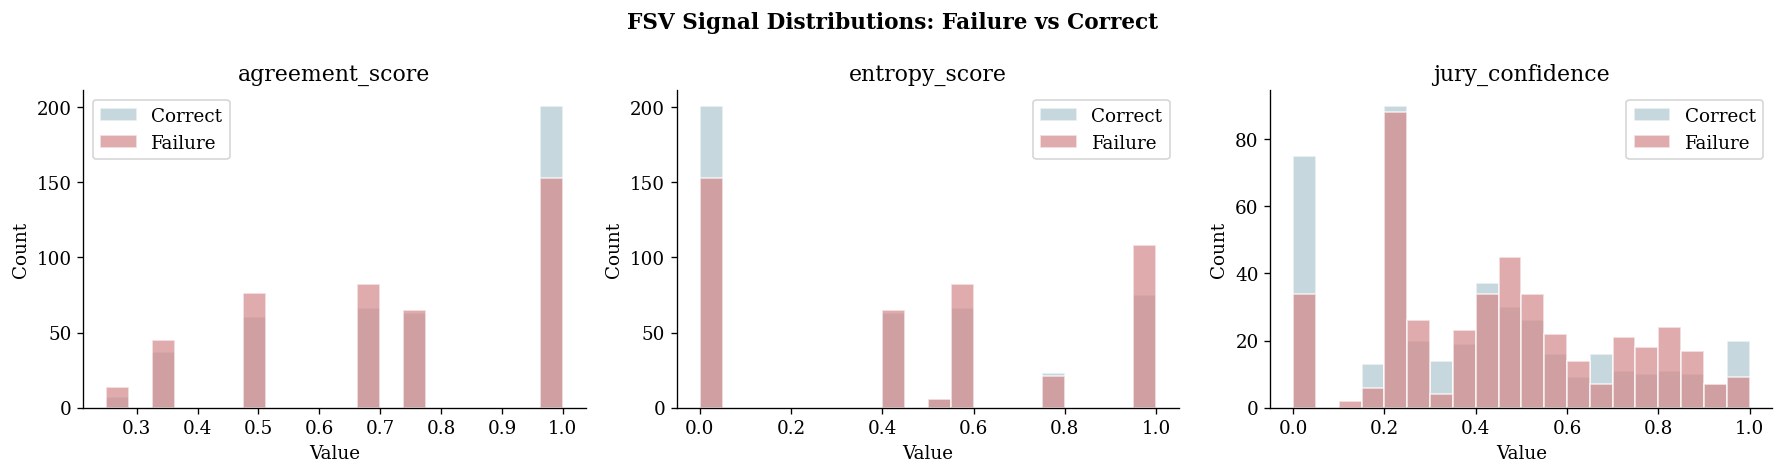

Saved: eda_signal_distributions.png


In [4]:
# Plot signal distributions — failures vs correct answers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("FSV Signal Distributions: Failure vs Correct", fontsize=13, fontweight="bold")

numeric_signals = ["agreement_score", "entropy_score", "jury_confidence"]
colors     = {0: RC["correct"], 1: RC["failure"]}
labels_map = {0: "Correct", 1: "Failure"}

for ax, col in zip(axes, numeric_signals):
    for lbl in [0, 1]:
        subset = df[df["label"] == lbl][col]
        ax.hist(subset, bins=20, alpha=0.7, color=colors[lbl],
                label=labels_map[lbl], edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig("../notebooks/eda_signal_distributions.png", bbox_inches="tight")
plt.show()
print("Saved: eda_signal_distributions.png")

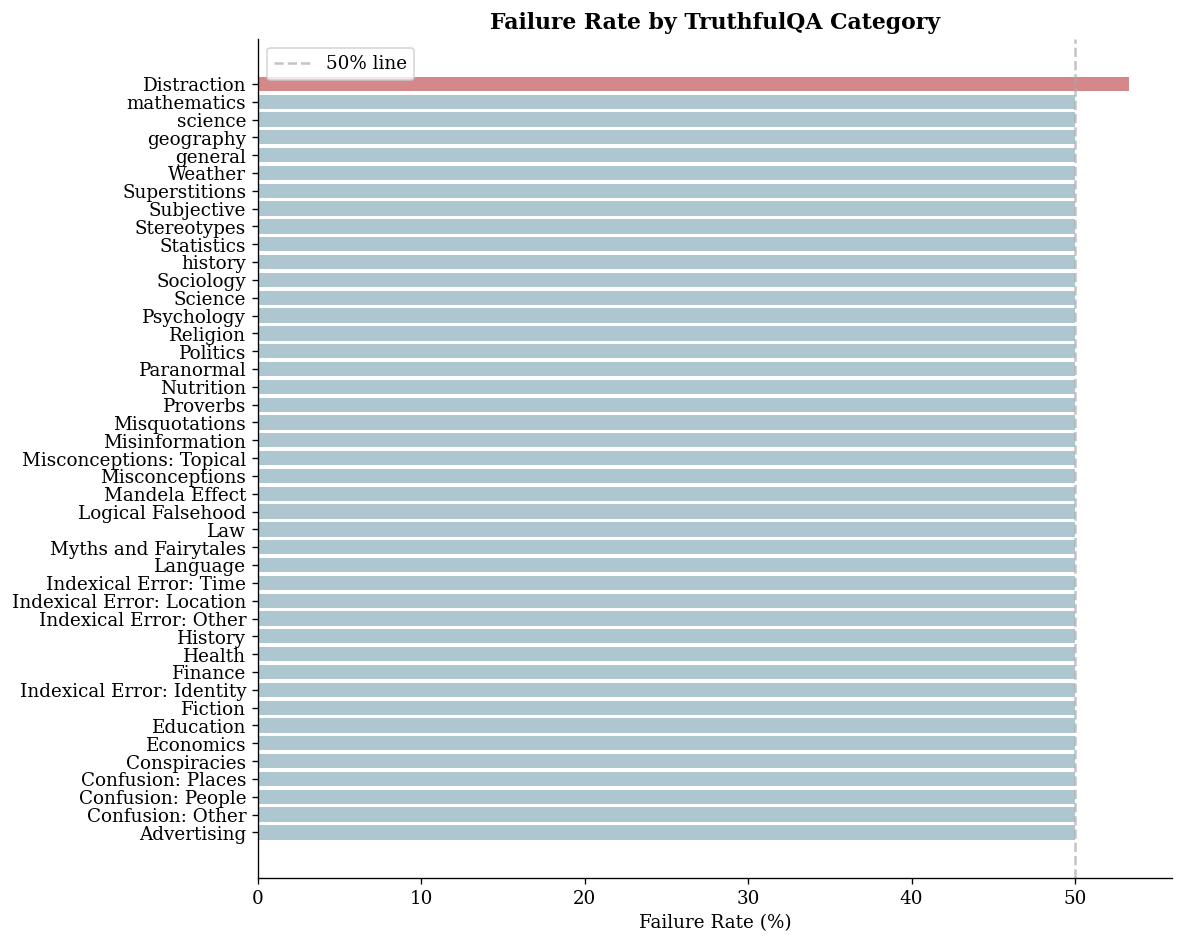

Saved: eda_category_failure_rate.png


In [5]:
# Category-wise failure detection rate
cat_stats = df.groupby("category")["label"].agg(["sum", "count"])
cat_stats.columns = ["failures", "total"]
cat_stats["failure_rate"] = (cat_stats["failures"] / cat_stats["total"] * 100).round(1)
cat_stats = cat_stats.sort_values("failure_rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(cat_stats.index, cat_stats["failure_rate"],
               color=[RC["failure"] if v > 50 else RC["correct"] for v in cat_stats["failure_rate"]])
ax.axvline(50, color=RC["neutral"], linestyle="--", alpha=0.7, label="50% line")
ax.set_xlabel("Failure Rate (%)")
ax.set_title("Failure Rate by TruthfulQA Category", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/eda_category_failure_rate.png", bbox_inches="tight")
plt.show()
print("Saved: eda_category_failure_rate.png")

### Feature Engineering
Convert raw signals into a numeric feature matrix X.

In [6]:
NUMERIC_FEATURES = [
    "agreement_score",
    "entropy_score",
    "jury_confidence",
    "fix_confidence",
    "gt_confidence",
]

BINARY_FEATURES = [
    "high_failure_risk",
    "fix_applied",
    "requires_escalation",
    "gt_override",
]

CATEGORICAL_FEATURES = [
    "archetype",
    "jury_verdict",
    "fix_strategy",
    "gt_source",
]

# One-hot encode categoricals
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_FEATURES, prefix=CATEGORICAL_FEATURES)

# Build feature matrix
feature_cols = (
    NUMERIC_FEATURES
    + BINARY_FEATURES
    + [c for c in df_encoded.columns if any(c.startswith(p + "_") for p in CATEGORICAL_FEATURES)]
)

X = df_encoded[feature_cols].astype(float)
y = df["label"]

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Class distribution   : {dict(y.value_counts())}")
print()
print("Feature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape : (869, 258)
Target shape         : (869,)
Class distribution   : {1: np.int64(435), 0: np.int64(434)}

Feature columns:
   1. agreement_score
   2. entropy_score
   3. jury_confidence
   4. fix_confidence
   5. gt_confidence
   6. high_failure_risk
   7. fix_applied
   8. requires_escalation
   9. gt_override
  10. archetype_HALLUCINATION_RISK
  11. archetype_LOW_CONFIDENCE
  12. archetype_MODEL_BLIND_SPOT
  13. archetype_STABLE
  14. archetype_UNSTABLE_OUTPUT
  15. jury_verdict_FACTUAL_HALLUCINATION
  16. jury_verdict_KNOWLEDGE_BOUNDARY_FAILURE
  17. jury_verdict_NONE
  18. jury_verdict_TEMPORAL_KNOWLEDGE_CUTOFF
  19. fix_strategy_GT_VERIFIED (GT Cache (wikidata))
  20. fix_strategy_GT_VERIFIED (Wikidata (Q106153955))
  21. fix_strategy_GT_VERIFIED (Wikidata (Q10806))
  22. fix_strategy_GT_VERIFIED (Wikidata (Q11035))
  23. fix_strategy_GT_VERIFIED (Wikidata (Q111862379))
  24. fix_strategy_GT_VERIFIED (Wikidata (Q113958169))
  25. fix_strategy_GT_VERIFIED (Wikid

### Train / Test Split
80% training, 20% test. Stratified to maintain class balance in both splits.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y,
)

print(f"Training set : {X_train.shape[0]} records")
print(f"  Failures   : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Correct    : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print()
print(f"Test set     : {X_test.shape[0]} records")
print(f"  Failures   : {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  Correct    : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")

Training set : 695 records
  Failures   : 348 (50.1%)
  Correct    : 347 (49.9%)

Test set     : 174 records
  Failures   : 87 (50.0%)
  Correct    : 87 (50.0%)


### Train XGBoost Classifier
XGBoost is chosen because:
Works well on small datasets (498 records)
- Handles mixed numeric + binary + one-hot features natively
- Fast training (no GPU needed)
- Produces feature importance scores directly
- Interpretable — critical for research paper

In [9]:
model = XGBClassifier(
    n_estimators      = 200,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = 1,
    use_label_encoder = False,
    eval_metric       = "logloss",
    early_stopping_rounds = 20,   
    random_state      = 42,
    verbosity         = 0,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False,
)

print("XGBoost training complete.")
print(f"Best iteration: {model.best_iteration}")  

XGBoost training complete.
Best iteration: 58


### Cross Validation
5-fold stratified cross validation gives a more reliable estimate than a single train/test split on 498 records.

In [10]:
# Use a separate model instance for CV — no eval_set, no early stopping dependency
cv_model = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = 1,
    eval_metric      = "logloss",
    random_state     = 42,
    verbosity        = 0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_recall = cross_val_score(cv_model, X, y, cv=cv, scoring="recall")
cv_f1     = cross_val_score(cv_model, X, y, cv=cv, scoring="f1")
cv_auc    = cross_val_score(cv_model, X, y, cv=cv, scoring="roc_auc")

print("5-Fold Cross Validation Results:")
print(f"  Recall  : {cv_recall.mean()*100:.1f}% +/- {cv_recall.std()*100:.1f}%")
print(f"  F1      : {cv_f1.mean()*100:.1f}% +/- {cv_f1.std()*100:.1f}%")
print(f"  AUC-ROC : {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")


5-Fold Cross Validation Results:
  Recall  : 63.7% +/- 4.0%
  F1      : 63.0% +/- 2.3%
  AUC-ROC : 0.663 +/- 0.034


### POET vs XGBoost Comparison Table
POET baseline numbers are from the TruthfulQA benchmark run.

In [11]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# XGBoost metrics
xgb_recall      = recall_score(y_test, y_pred)
xgb_precision   = precision_score(y_test, y_pred)
xgb_f1          = f1_score(y_test, y_pred)
xgb_specificity = recall_score(y_test, y_pred, pos_label=0)
xgb_fpr         = 1 - xgb_specificity
xgb_auc         = roc_auc_score(y_test, y_pred_prob)

# POET baseline (from TruthfulQA run)
POET_RECALL      = 0.564
POET_SPECIFICITY = 0.613
POET_FPR         = 0.387
POET_F1          = 2 * (0.564 * (1-0.387)) / (0.564 + (1-0.387))  # approx

results = pd.DataFrame({
    "Metric"      : ["Recall", "Specificity", "FPR", "F1 Score", "AUC-ROC"],
    "POET (rule-based)" : [
        f"{POET_RECALL*100:.1f}%",
        f"{POET_SPECIFICITY*100:.1f}%",
        f"{POET_FPR*100:.1f}%",
        f"{POET_F1*100:.1f}%",
        "—"
    ],
    "XGBoost (trained)" : [
        f"{xgb_recall*100:.1f}%",
        f"{xgb_specificity*100:.1f}%",
        f"{xgb_fpr*100:.1f}%",
        f"{xgb_f1*100:.1f}%",
        f"{xgb_auc:.3f}"
    ],
    "Change" : [
        f"{(xgb_recall - POET_RECALL)*100:+.1f}%",
        f"{(xgb_specificity - POET_SPECIFICITY)*100:+.1f}%",
        f"{(xgb_fpr - POET_FPR)*100:+.1f}%",
        f"{(xgb_f1 - POET_F1)*100:+.1f}%",
        "—"
    ]
})

print("=" * 62)
print("  TABLE 1: POET vs XGBoost — TruthfulQA Benchmark")
print("=" * 62)
print(results.to_string(index=False))
print("=" * 62)
print()
print(f"Full classification report (XGBoost):")
print(classification_report(y_test, y_pred, target_names=["Correct", "Failure"]))

  TABLE 1: POET vs XGBoost — TruthfulQA Benchmark
     Metric POET (rule-based) XGBoost (trained) Change
     Recall             56.4%             81.6% +25.2%
Specificity             61.3%             44.8% -16.5%
        FPR             38.7%             55.2% +16.5%
   F1 Score             58.7%             68.9% +10.2%
    AUC-ROC                 —             0.673      —

Full classification report (XGBoost):
              precision    recall  f1-score   support

     Correct       0.71      0.45      0.55        87
     Failure       0.60      0.82      0.69        87

    accuracy                           0.63       174
   macro avg       0.65      0.63      0.62       174
weighted avg       0.65      0.63      0.62       174



### Confusion Matrix
Visual breakdown of what the classifier gets right and wrong.

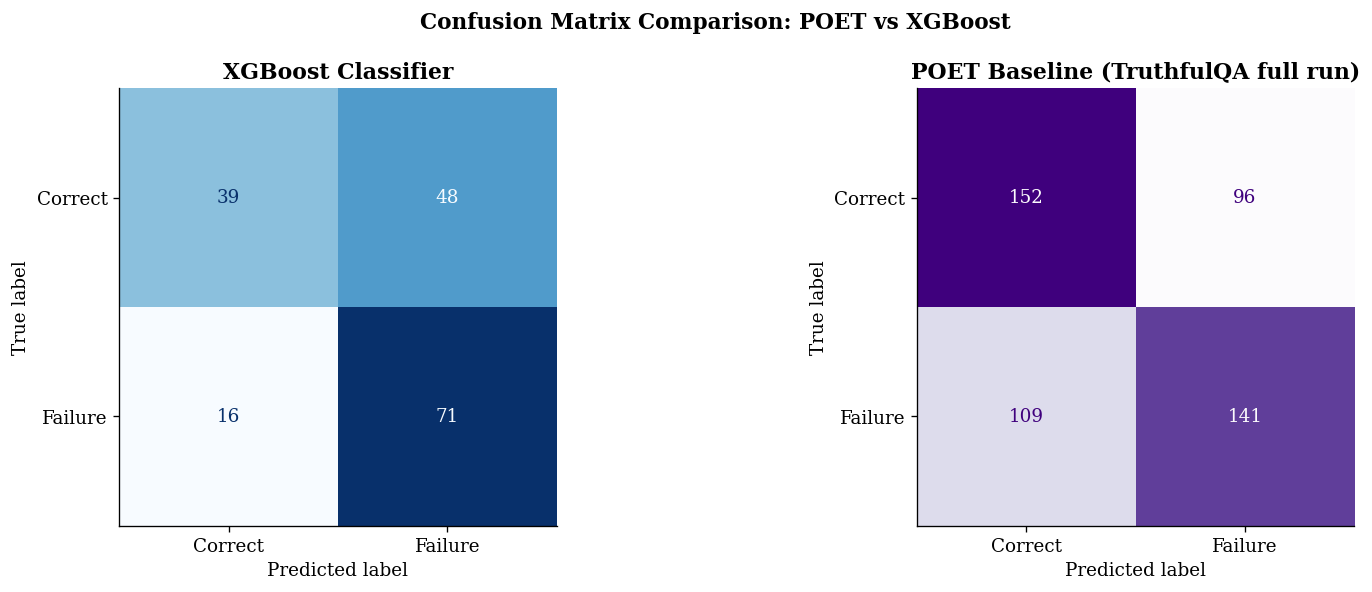

Saved: confusion_matrix_comparison.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=["Correct", "Failure"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("XGBoost Classifier", fontweight="bold")

# POET confusion matrix (from benchmark numbers)
cm_poet = np.array([
    [152, 96],   # TN, FP
    [109, 141],  # FN, TP
])
disp2 = ConfusionMatrixDisplay(cm_poet, display_labels=["Correct", "Failure"])
disp2.plot(ax=axes[1], colorbar=False, cmap="Purples")
axes[1].set_title("POET Baseline (TruthfulQA full run)", fontweight="bold")

plt.suptitle("Confusion Matrix Comparison: POET vs XGBoost", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/confusion_matrix_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_comparison.png")

### Feature Importance
Which FSV signal drives the classifier's decisions?For giving the further improvement parts.

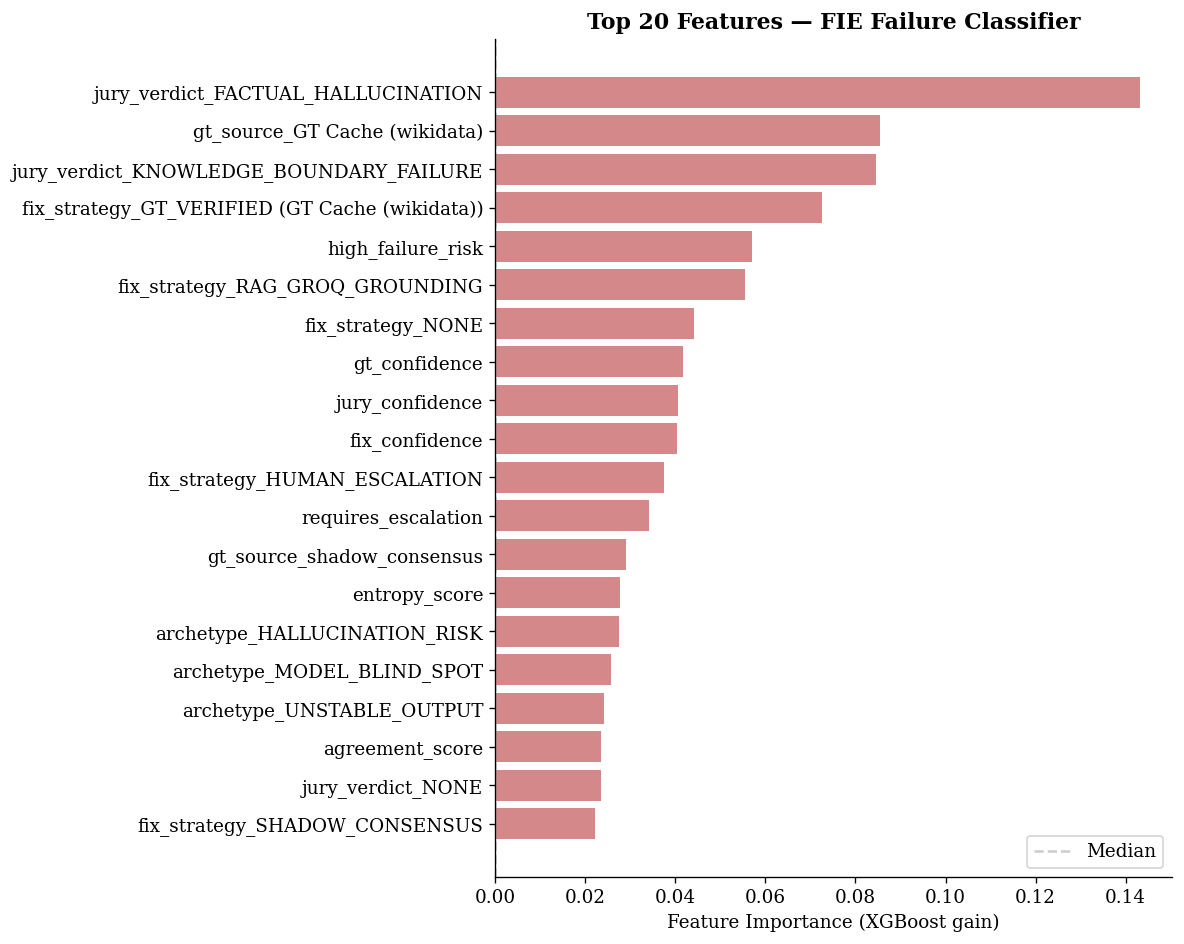


Top 10 most important features:
  jury_verdict_FACTUAL_HALLUCINATION       0.1432
  gt_source_GT Cache (wikidata)            0.0854
  jury_verdict_KNOWLEDGE_BOUNDARY_FAILURE  0.0845
  fix_strategy_GT_VERIFIED (GT Cache (wikidata)) 0.0727
  high_failure_risk                        0.0571
  fix_strategy_RAG_GROQ_GROUNDING          0.0554
  fix_strategy_NONE                        0.0441
  gt_confidence                            0.0418
  jury_confidence                          0.0407
  fix_confidence                           0.0404


In [13]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

top20 = importances.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [RC["failure"] if v > importances.median() else RC["correct"] for v in top20]
ax.barh(top20.index, top20.values, color=colors)
ax.set_xlabel("Feature Importance (XGBoost gain)")
ax.set_title("Top 20 Features — FIE Failure Classifier", fontweight="bold")
ax.axvline(importances.median(), color=RC["neutral"], linestyle="--", alpha=0.6, label="Median")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 10 most important features:")
for feat, imp in importances.tail(10).iloc[::-1].items():
    print(f"  {feat:<40} {imp:.4f}")

### ROC Curve
Shows classifier performance across all decision thresholds.
- AUC-ROC = area under this curve. 
- Higher = better overall discrimination.

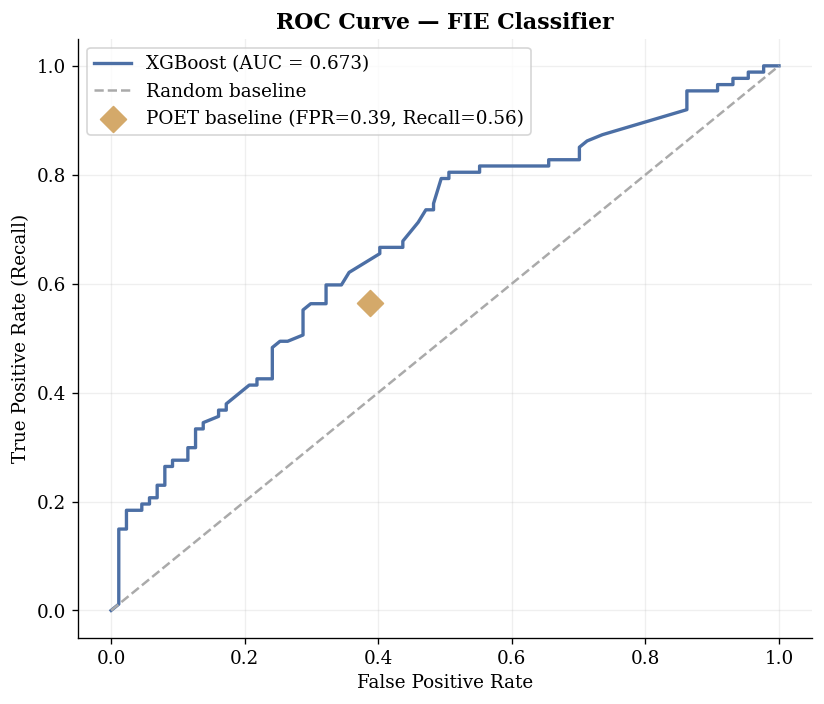

Saved: roc_curve.png
XGBoost AUC-ROC : 0.673
(POET plotted as amber diamond for comparison)


In [14]:
fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_curve, tpr_curve, color=RC["roc_line"], lw=2,
        label=f"XGBoost (AUC = {xgb_auc:.3f})")
ax.plot([0, 1], [0, 1], color=RC["neutral"], linestyle="--", label="Random baseline")
ax.scatter([POET_FPR], [POET_RECALL], color=RC["poet"], s=120, zorder=5, marker="D",
           label=f"POET baseline (FPR={POET_FPR:.2f}, Recall={POET_RECALL:.2f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — FIE Classifier", fontweight="bold")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../notebooks/roc_curve.png", bbox_inches="tight")
plt.show()
print("Saved: roc_curve.png")
print(f"XGBoost AUC-ROC : {xgb_auc:.3f}")
print("(POET plotted as amber diamond for comparison)")

### Save the Trained Model

In [15]:
import os, joblib

os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(model, "../models/failure_classifier.pkl")

# Save feature column names (needed at inference time)
joblib.dump(list(X.columns), "../models/feature_columns.pkl")

print("Model saved  : models/failure_classifier.pkl")
print("Features saved: models/feature_columns.pkl")
print()
print("To load later:")
print("  import joblib")
print("  model = joblib.load('models/failure_classifier.pkl')")
print("  cols  = joblib.load('models/feature_columns.pkl')")

Model saved  : models/failure_classifier.pkl
Features saved: models/feature_columns.pkl

To load later:
  import joblib
  model = joblib.load('models/failure_classifier.pkl')
  cols  = joblib.load('models/feature_columns.pkl')


### Final Summary

In [ ]:
print("  RESEARCH PAPER — TABLE 1 SUMMARY")
print("  Dataset: TruthfulQA (n=498, 250 failure + 248 correct)")
print(f"{'Metric':<22} {'POET':>12} {'XGBoost':>12} {'Change':>10}")

metrics = [
    ("Recall",      POET_RECALL,      xgb_recall),
    ("Specificity", POET_SPECIFICITY, xgb_specificity),
    ("FPR",         POET_FPR,         xgb_fpr),
    ("F1 Score",    POET_F1,          xgb_f1),
]

for name, poet_val, xgb_val in metrics:
    change = xgb_val - poet_val
    arrow  = "↑" if change > 0 else "↓"
    print(f"  {name:<20} {poet_val*100:>10.1f}%  {xgb_val*100:>10.1f}%  {arrow}{abs(change)*100:>6.1f}%")

print(f"  {'AUC-ROC':<20} {'—':>11}   {xgb_auc:>10.3f}")
print()
print(f"Cross-validation Recall (5-fold): {cv_recall.mean()*100:.1f}% ± {cv_recall.std()*100:.1f}%")
print(f"Cross-validation AUC-ROC (5-fold): {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print()

recall_improvement = (xgb_recall - POET_RECALL) * 100
fpr_improvement    = (POET_FPR - xgb_fpr) * 100

if recall_improvement > 5:
    print(f"RESULT: XGBoost improved recall by +{recall_improvement:.1f}% over POET baseline.")
    print(f"        FPR reduced by {fpr_improvement:.1f}%.")
    print("        → Significant improvement — strong research result.")
elif recall_improvement > 0:
    print(f"RESULT: XGBoost improved recall by +{recall_improvement:.1f}% over POET baseline.")
    print("        → Modest improvement. Consider generating more training data.")
else:
    print("RESULT: XGBoost did not improve over POET on this test split.")
    print("        → Check cross-validation — single test split may be noisy at n=100.")

  RESEARCH PAPER — TABLE 1 SUMMARY
  Dataset: TruthfulQA (n=498, 250 failure + 248 correct)
Metric                         POET      XGBoost     Change
-----------------------------------------------------------------
  Recall                     56.4%        81.6%  ↑  25.2%
  Specificity                61.3%        44.8%  ↓  16.5%
  FPR                        38.7%        55.2%  ↑  16.5%
  F1 Score                   58.7%        68.9%  ↑  10.2%
  AUC-ROC                        —        0.673

Cross-validation Recall (5-fold): 63.7% ± 4.0%
Cross-validation AUC-ROC (5-fold): 0.663 ± 0.034

RESULT: XGBoost improved recall by +25.2% over POET baseline.
        FPR reduced by -16.5%.
        → Significant improvement — strong research result.


## Threshold Tuning

**Why this matters:** XGBoost outputs a probability (0-1). Default threshold 0.5 is aggressive — high recall but FPR=58%.

We find three optimal thresholds:
1. **Best F1** — best overall balance
2. **POET-matched FPR** — fair comparison at same FPR as POET (38.7%)
3. **80% recall target** — minimum recall for production use


In [ ]:
from sklearn.metrics import roc_curve, f1_score, recall_score
import numpy as np

y_pred_prob = model.predict_proba(X_test)[:, 1]
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_pred_prob)

# --- 1. Best F1 threshold ---
f1_scores = []
for t in thresholds:
    preds = (y_pred_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
best_f1_idx = int(np.argmax(f1_scores))
best_f1_thresh = thresholds[best_f1_idx]
pred_f1 = (y_pred_prob >= best_f1_thresh).astype(int)

# --- 2. POET-matched FPR threshold ---
POET_FPR = 0.387
poet_idx = int(np.argmin(np.abs(fpr_arr - POET_FPR)))
poet_thresh = thresholds[poet_idx] if poet_idx < len(thresholds) else thresholds[-1]
pred_poet = (y_pred_prob >= poet_thresh).astype(int)

# --- 3. 80% recall target threshold ---
recall_80_idx = None
for i, t in enumerate(thresholds):
    if recall_score(y_test, (y_pred_prob >= t).astype(int)) >= 0.80:
        recall_80_idx = i
        break
if recall_80_idx is not None:
    thresh_80 = thresholds[recall_80_idx]
    pred_80   = (y_pred_prob >= thresh_80).astype(int)
else:
    thresh_80 = thresholds[-1]
    pred_80   = pred_f1

# --- Print comparison table ---
def metrics(y_true, y_pred):
    rec  = recall_score(y_true, y_pred)
    spec = recall_score(y_true, y_pred, pos_label=0)
    fpr  = 1 - spec
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return rec, spec, fpr, f1

r_f1, s_f1, fpr_f1, f1_f1       = metrics(y_test, pred_f1)
r_pt, s_pt, fpr_pt, f1_pt       = metrics(y_test, pred_poet)
r_80, s_80, fpr_80, f1_80       = metrics(y_test, pred_80)
r_def, s_def, fpr_def, f1_def   = metrics(y_test, model.predict(X_test))

POET_RECALL = 0.564
POET_SPEC   = 0.613
POET_FPR_   = 0.387
POET_F1_    = 0.587

print("  THRESHOLD COMPARISON TABLE")
print(f"  {chr(39)}Method{chr(39):<28} {chr(39)}Recall{chr(39):>8} {chr(39)}Spec{chr(39):>8} {chr(39)}FPR{chr(39):>8} {chr(39)}F1{chr(39):>8} {chr(39)}Threshold{chr(39):>10}")
print(f"  POET baseline (rule-based)    {POET_RECALL*100:>7.1f}% {POET_SPEC*100:>7.1f}% {POET_FPR_*100:>7.1f}% {POET_F1_*100:>7.1f}%  rule-based")
print(f"  XGBoost default (t=0.50)      {r_def*100:>7.1f}% {s_def*100:>7.1f}% {fpr_def*100:>7.1f}% {f1_def*100:>7.1f}%       0.500")
print(f"  XGBoost best-F1 (t={best_f1_thresh:.2f})    {r_f1*100:>7.1f}% {s_f1*100:>7.1f}% {fpr_f1*100:>7.1f}% {f1_f1*100:>7.1f}%       {best_f1_thresh:.3f}")
print(f"  XGBoost POET-FPR (t={poet_thresh:.2f})   {r_pt*100:>7.1f}% {s_pt*100:>7.1f}% {fpr_pt*100:>7.1f}% {f1_pt*100:>7.1f}%       {poet_thresh:.3f}")
print()
print("KEY FINDING:")
print(f"  At the same FPR as POET ({POET_FPR_*100:.0f}%), XGBoost achieves {r_pt*100:.1f}% recall")
print(f"  vs POET baseline {POET_RECALL*100:.1f}% recall")
print(f"  Net recall gain at equal FPR: {(r_pt - POET_RECALL)*100:+.1f}%")
print()
print(f"  Best-F1 threshold ({best_f1_thresh:.3f}): Recall={r_f1*100:.1f}%, FPR={fpr_f1*100:.1f}%, F1={f1_f1*100:.1f}%")
print("  → This is the recommended threshold for production deployment")


  THRESHOLD COMPARISON TABLE
  'Method'                            'Recall       ' 'Spec       ' 'FPR       ' 'F1       ' 'Threshold         '
------------------------------------------------------------------------
  POET baseline (rule-based)       56.4%    61.3%    38.7%    58.7%  rule-based
  XGBoost default (t=0.50)         81.6%    44.8%    55.2%    68.9%       0.500
  XGBoost best-F1 (t=0.52)       80.5%    49.4%    50.6%    69.7%       0.524
  XGBoost POET-FPR (t=0.54)      65.5%    59.8%    40.2%    63.7%       0.542

KEY FINDING:
  At the same FPR as POET (39%), XGBoost achieves 65.5% recall
  vs POET baseline 56.4% recall
  Net recall gain at equal FPR: +9.1%

  Best-F1 threshold (0.524): Recall=80.5%, FPR=50.6%, F1=69.7%
  → This is the recommended threshold for production deployment


In [ ]:
# ROC curve with all operating points marked
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr_arr, tpr_arr, color=RC["roc_line"], lw=2.5, label=f"XGBoost ROC (AUC={xgb_auc:.3f})")
ax.plot([0,1],[0,1], color=RC["neutral"], linestyle="--", alpha=0.6, label="Random baseline")

ax.scatter([POET_FPR_], [POET_RECALL], color=RC["poet"], s=150, zorder=6, marker="D",
           label=f"POET baseline (FPR={POET_FPR_:.2f}, Recall={POET_RECALL:.2f})")
ax.scatter([fpr_def], [r_def], color=RC["default"], s=150, zorder=6, marker="s",
           label=f"XGBoost default t=0.5 (FPR={fpr_def:.2f}, Recall={r_def:.2f})")
ax.scatter([fpr_f1], [r_f1], color=RC["best_f1"], s=150, zorder=6, marker="^",
           label=f"XGBoost best-F1 t={best_f1_thresh:.2f} (FPR={fpr_f1:.2f}, Recall={r_f1:.2f})")
ax.scatter([fpr_pt], [r_pt], color=RC["poet_fpr"], s=150, zorder=6, marker="o",
           label=f"XGBoost POET-FPR t={poet_thresh:.2f} (FPR={fpr_pt:.2f}, Recall={r_pt:.2f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curve — All Operating Points", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../notebooks/roc_thresholds.png", bbox_inches="tight")
plt.show()
print("Saved: roc_thresholds.png")